In [ ]:
import pandas as pd
df = pd.read_csv("../data/SuperStore_Orders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [5]:
df.shape

(51290, 21)

In [6]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

## data type conversion

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

In [8]:
df[['order_date', 'ship_date']].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

### new features

In [9]:
df['month'] = df['order_date'].dt.month_name()
df['year'] = df['order_date'].dt.year
df['quarter'] = df['order_date'].dt.quarter

In [10]:
df[['order_date','month','year','quarter']].head()

,order_date,month,year,quarter
0,2011-01-01,January,2011,1
1,2011-01-01,January,2011,1
2,2011-01-01,January,2011,1
3,2011-01-01,January,2011,1
4,2011-01-01,January,2011,1


## Business KPI Analysis

In [12]:
df[['sales','profit','shipping_cost']].dtypes

sales             object
profit           float64
shipping_cost    float64
dtype: object

In [13]:
df['sales'].head(10)
df['sales'].sample(10)

14661    207
44187     35
25755      9
27057     41
16709    825
38071    529
31166     71
47938     58
49335    238
32365    284
Name: sales, dtype: object

In [17]:
df['sales'] = df['sales'].astype(str)
df['sales'] = df['sales'].str.replace(',', '')
df['sales'] = df['sales'].astype(float)

In [18]:
print(df['sales'].dtype)

float64


In [20]:
print(f"Total Sales: ${df['sales'].sum():,.2f}")
print(f"Total Profit: ${df['profit'].sum():,.2f}")
print("Total Orders:", df['order_id'].nunique())
print("Total Customers:", df['customer_name'].nunique())

Total Sales: $12,642,905.00
Total Profit: $1,469,034.82
Total Orders: 25035
Total Customers: 795


# Exploratory Data Analysis(EDA):

#### sales by category

In [23]:
sales_category = df.groupby('category')['sales'].sum()
print(sales_category)

category
Furniture          4110884.0
Office Supplies    3787330.0
Technology         4744691.0
Name: sales, dtype: float64


#### profit by category

In [24]:
profit_category = df.groupby('category')['profit'].sum()
print(profit_category)

category
Furniture          286782.25380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64


#### sales by region

In [25]:
sales_region = df.groupby('region')['sales'].sum()
print(sales_region)

region
Africa             783776.0
Canada              66932.0
Caribbean          324281.0
Central           2822399.0
Central Asia       752839.0
EMEA               806184.0
East               678834.0
North             1248192.0
North Asia         848349.0
Oceania           1100207.0
South             1600960.0
Southeast Asia     884438.0
West               725514.0
Name: sales, dtype: float64


#### profit by region

In [26]:
profit_region = df.groupby('region')['profit'].sum()
print(profit_region)

region
Africa             88871.63100
Canada             17817.39000
Caribbean          34571.32104
Central           311403.98164
Central Asia      132480.18700
EMEA               43897.97100
East               91522.78000
North             194597.95252
North Asia        165578.42100
Oceania           121666.64200
South             140355.76618
Southeast Asia     17852.32900
West              108418.44890
Name: profit, dtype: float64


#### month column and monthly sales

In [27]:
df['month'] = df['order_date'].dt.month_name()
df[['order_date','month']].head()

,order_date,month
0,2011-01-01,January
1,2011-01-01,January
2,2011-01-01,January
3,2011-01-01,January
4,2011-01-01,January


In [28]:
monthly_sales = df.groupby('month')['sales'].sum()
print(monthly_sales)

month
April         698603.0
August       1293852.0
December     1580816.0
February      543768.0
January       675141.0
July          749423.0
June         1269751.0
March         770519.0
May           904061.0
November     1551319.0
October      1168220.0
September    1437432.0
Name: sales, dtype: float64


### top 10 products in sales , customers

In [30]:
top_products = df.groupby('product_name')['sales'].sum()
top_products = top_products.sort_values(ascending=False)
print(top_products.head(10))

product_name
Apple Smart Phone, Full Size                                86936.0
Cisco Smart Phone, Full Size                                76441.0
Motorola Smart Phone, Full Size                             73159.0
Nokia Smart Phone, Full Size                                71904.0
Canon imageCLASS 2200 Advanced Copier                       61600.0
Hon Executive Leather Armchair, Adjustable                  58200.0
Office Star Executive Leather Armchair, Adjustable          50667.0
Harbour Creations Executive Leather Armchair, Adjustable    50120.0
Samsung Smart Phone, Cordless                               48654.0
Nokia Smart Phone, with Caller ID                           47880.0
Name: sales, dtype: float64


In [31]:
top_customers = df.groupby('customer_name')['sales'].sum()
top_customers = top_customers.sort_values(ascending=False)
print(top_customers.head(10))

customer_name
Tom Ashbrook          40489.0
Tamara Chand          37453.0
Greg Tran             35552.0
Christopher Conant    35187.0
Sean Miller           35170.0
Bart Watters          32315.0
Natalie Fritzler      31778.0
Fred Hopkins          30404.0
Jane Waco             30288.0
Hunter Lopez          30246.0
Name: sales, dtype: float64


### sales in market and segment

In [32]:
market_sales = df.groupby('market')['sales'].sum()
print(market_sales)

market
APAC      3585833.0
Africa     783776.0
Canada      66932.0
EMEA       806184.0
EU        2938139.0
LATAM     2164687.0
US        2297354.0
Name: sales, dtype: float64


In [33]:
segment_sales = df.groupby('segment')['sales'].sum()
print(segment_sales)

segment
Consumer       6508141.0
Corporate      3824808.0
Home Office    2309956.0
Name: sales, dtype: float64


## charts

#### slaes by category

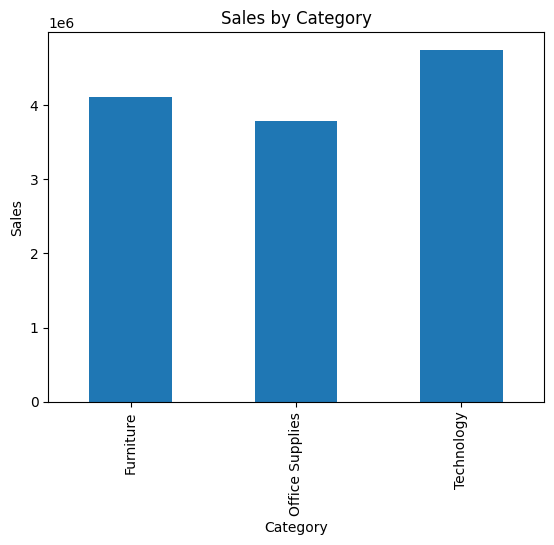

In [40]:
import matplotlib.pyplot as plt
sales_category = df.groupby('category')['sales'].sum()
sales_category.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

#### profit by category

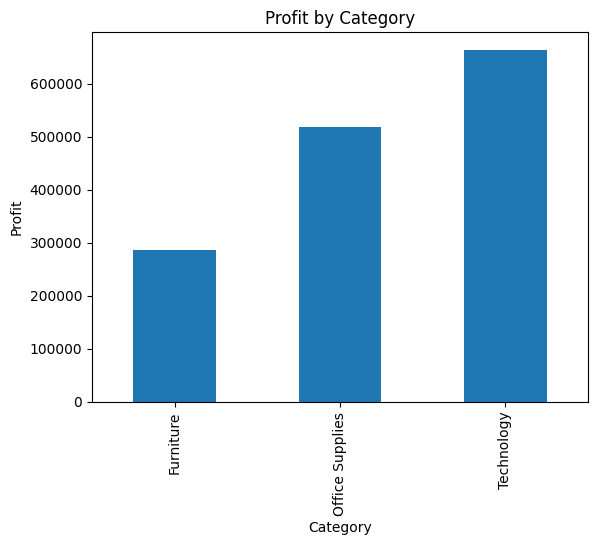

In [34]:
profit_category = df.groupby('category')['profit'].sum()
profit_category.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

#### slaes by region

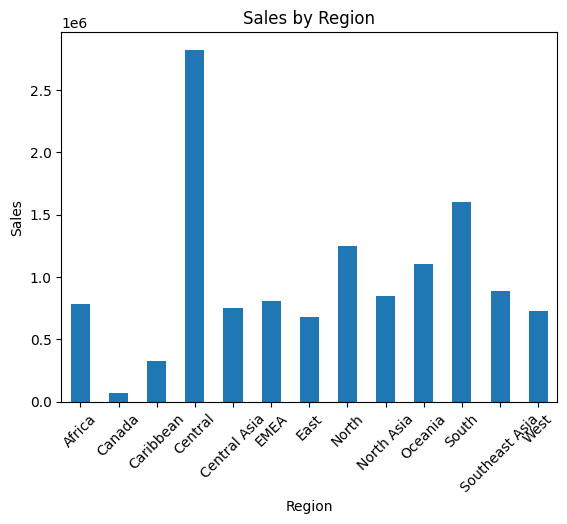

In [ ]:
sales_region = df.groupby('region')['sales'].sum()
sales_region.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

#### profit by region

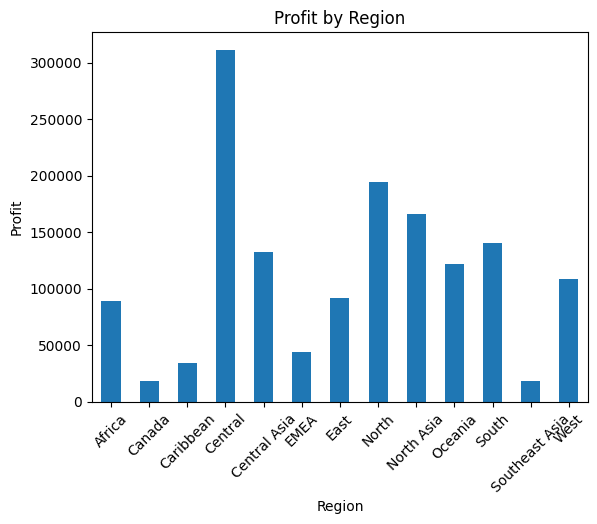

In [36]:
profit_region = df.groupby('region')['profit'].sum()
profit_region.plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

#### monthly sales trend

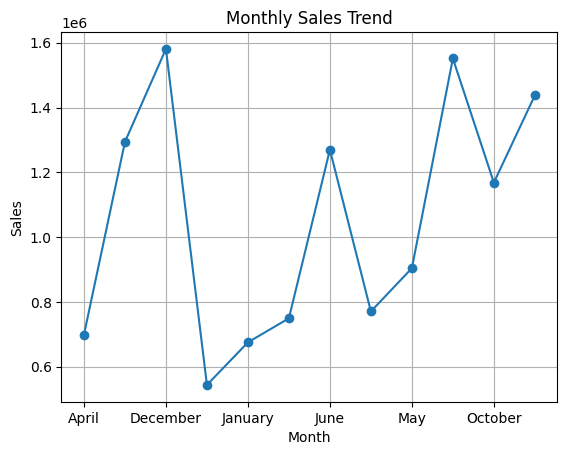

In [37]:
monthly_sales = df.groupby('month')['sales'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

#### discount Vs profit

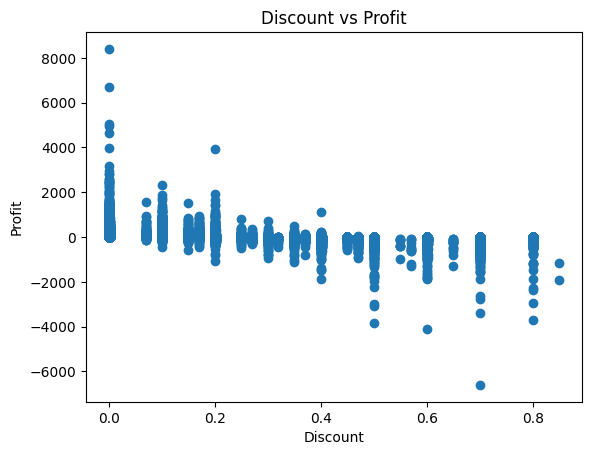

In [38]:
plt.scatter(df['discount'], df['profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

#### sales vs profit

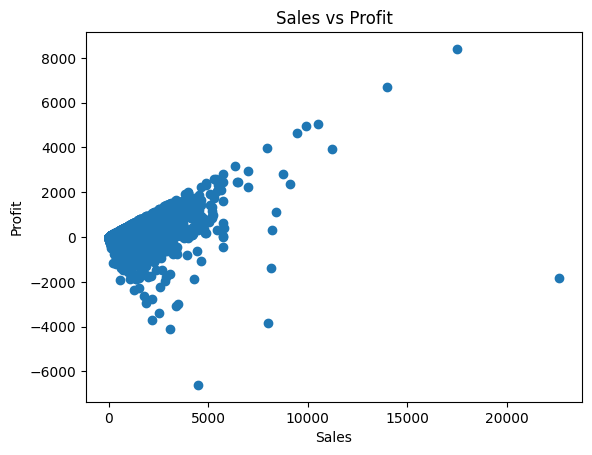

In [39]:
plt.scatter(df['sales'], df['profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

## Business Insights

###### Technology generated the highest sales and profit.
###### Consumer segment contributed the highest revenue.
###### Central region achieved the highest sales and profit.
###### Furniture generated high sales but lower profit compared to Technology.
###### Canada showed the lowest sales and profit performance.